## **1. 필요한 패키지 import**

In [7]:
import io
import os
import math
import copy
import pickle
import zipfile
from textwrap import wrap
from pathlib import Path
from itertools import zip_longest
from collections import defaultdict
from urllib.error import URLError
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch import optim
from torch.nn import functional as F
from torch.optim.lr_scheduler import _LRScheduler

In [8]:
plt.style.use('ggplot')

In [9]:
def set_random_seed(state=1):
    gens = (np.random.seed, torch.manual_seed, torch.cuda.manual_seed)
    for set_state in gens:
        set_state(state)

In [10]:
RANDOM_STATE = 1
set_random_seed(RANDOM_STATE)

## **2. 데이터셋 로드**

- MovieLens(ML) Dataset: 영화 추천 시스템 연구에서 가장 많이 쓰이는 추천 시스템용 공개 데이터셋
- 사용자들이 영화에 매긴 평점(rating) 데이터를 이용해서
  - 사용자 취향 분석
  - 영화 추천 모델 개발
  - 협업 필터링 / 딥러닝 추천 시스템 실험
- 을 할 수 있도록 만든 데이터

In [13]:
# 데이터셋 직접 다운로드

!wget https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!unzip ml-latest-small.zip

--2026-03-10 00:43:29--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘ml-latest-small.zip’

ml-latest-small.zip 100%[===================>] 955.28K   897KB/s    in 1.1s    

2026-03-10 00:43:31 (897 KB/s) - ‘ml-latest-small.zip’ saved [978202/978202]

Archive:  ml-latest-small.zip
   creating: ml-latest-small/
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.csv  
  inflating: ml-latest-small/ratings.csv  
  inflating: ml-latest-small/README.txt  
  inflating: ml-latest-small/movies.csv  


In [14]:
# 여러 데이터셋 중 small size로 선정

data_path = "./ml-latest-small/"

In [15]:
def read_data(path):
    files = {}
    for filename in os.listdir(path):
        stem, suffix =  os.path.splitext(filename)
        file_path = os.path.join(path,filename)
        print(filename)
        if suffix == '.csv':
            files[stem] = pd.read_csv(file_path)
        elif suffix == '.dat':
            if stem == 'ratings':
                columns = ['userId', 'movieId', 'rating', 'timestamp']
            else:
                columns = ['movieId', 'title', 'genres']
            data = pd.read_csv(file_path, sep='::', names=columns, engine='python')
            files[stem] = data
    return files['ratings'], files['movies']

In [17]:
ratings, movies = read_data('ml-latest-small/')

movies.csv
links.csv
tags.csv
ratings.csv
README.txt


In [18]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [19]:
# 미리 찍어보기 !

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [21]:
# 평점을 많이 남긴 상위 사용자와 많이 평가된 영화만 골라서 사용자-영화 평점 테이블을 만드는 함수

def tabular_preview(ratings, n=15):
    """Creates a cross-tabular view of users vs movies."""

    user_groups = ratings.groupby('userId')['rating'].count()
    top_users = user_groups.sort_values(ascending=False)[:n]

    movie_groups = ratings.groupby('movieId')['rating'].count()
    top_movies = movie_groups.sort_values(ascending=False)[:n]

    top = (
        ratings.
        join(top_users, rsuffix='_r', how='inner', on='userId').
        join(top_movies, rsuffix='_r', how='inner', on='movieId'))

    return pd.crosstab(top.userId, top.movieId, top.rating, aggfunc=np.sum)

In [22]:
tabular_preview(ratings, 20)

/tmp/ipykernel_15228/3933855387.py:15: FutureWarning: The provided callable <function sum at 0x7bfa05669300> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  return pd.crosstab(top.userId, top.movieId, top.rating, aggfunc=np.sum)


movieId,1,47,50,110,150,260,296,318,356,480,527,589,593,780,1196,1198,2571,2858,2959,4993
userId,,,,,,,,,,,,,,,,,,,,
68,2.5,4.0,3.0,2.5,3.0,5.0,2.0,3.0,3.5,3.5,4.0,3.5,3.5,4.0,5.0,5.0,4.5,5.0,2.5,4.5
177,5.0,4.5,4.0,NaN,4.0,2.5,5.0,5.0,5.0,3.5,4.5,NaN,5.0,3.5,3.0,3.5,3.0,4.0,4.0,2.0
182,4.0,4.0,4.5,3.5,2.5,3.5,5.0,4.5,5.0,3.5,4.0,2.0,4.5,1.5,3.0,3.5,5.0,5.0,5.0,3.0
232,3.5,4.5,NaN,4.5,4.5,4.5,5.0,5.0,4.0,3.0,4.5,4.0,NaN,3.5,4.5,4.5,4.5,NaN,4.5,3.5
249,4.0,5.0,4.0,5.0,2.5,5.0,4.0,4.5,4.5,4.0,4.5,4.0,4.0,4.0,5.0,5.0,5.0,4.5,5.0,5.0
274,4.0,4.0,4.0,4.5,NaN,3.0,5.0,4.5,4.5,3.5,4.0,4.5,4.0,3.5,4.5,4.0,4.0,5.0,5.0,3.0
288,4.5,3.5,NaN,5.0,3.0,5.0,5.0,5.0,5.0,2.0,5.0,4.0,5.0,1.0,4.5,5.0,3.0,NaN,3.5,5.0
298,2.0,4.0,3.5,3.0,NaN,4.0,4.5,3.5,3.0,4.0,NaN,4.0,NaN,2.5,4.0,4.5,4.0,4.0,5.0,4.0
307,4.0,4.0,4.5,3.5,2.0,3.5,4.5,4.5,4.0,3.5,4.5,2.5,4.5,2.0,3.0,4.0,3.5,4.0,4.0,3.0


## **3. 데이터 전처리**

In [23]:
def create_dataset(ratings, top=None):
    if top is not None:
        ratings.groupby('userId')['rating'].count()

    unique_users = ratings.userId.unique() # userId 인덱스로 변환
    user_to_index = {old: new for new, old in enumerate(unique_users)}
    new_users = ratings.userId.map(user_to_index)

    unique_movies = ratings.movieId.unique() # movieId 인덱스로 변환
    movie_to_index = {old: new for new, old in enumerate(unique_movies)}
    new_movies = ratings.movieId.map(movie_to_index)

    n_users = unique_users.shape[0]
    n_movies = unique_movies.shape[0]

    X = pd.DataFrame({'user_id': new_users, 'movie_id': new_movies})
    y = ratings['rating'].astype(np.float32)
    return (n_users, n_movies), (X, y), (user_to_index, movie_to_index) # original userId -> 0~N 인덱스로 id 재정렬

In [24]:
# 딥러닝 모델에 입력할 데이터셋 정리

 (n, m), (X, y), _ = create_dataset(ratings)
print(f'Embeddings: {n} users, {m} movies')
print(f'Dataset shape: {X.shape}')
print(f'Target shape: {y.shape}')

Embeddings: 610 users, 9724 movies
Dataset shape: (100836, 2)
Target shape: (100836,)


In [25]:
class ReviewsIterator:

    def __init__(self, X, y, batch_size=32, shuffle=True):
        X, y = np.asarray(X), np.asarray(y)

        if shuffle:
            index = np.random.permutation(X.shape[0])
            X, y = X[index], y[index]

        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.n_batches = int(math.ceil(X.shape[0] // batch_size))
        self._current = 0

    def __iter__(self):
        return self

    def __next__(self):
        return self.next()

    def next(self):
        if self._current >= self.n_batches:
            raise StopIteration()
        k = self._current
        self._current += 1
        bs = self.batch_size
        return self.X[k*bs:(k + 1)*bs], self.y[k*bs:(k + 1)*bs]

In [26]:
def batches(X, y, bs=32, shuffle=True):
    for xb, yb in ReviewsIterator(X, y, bs, shuffle):
        xb = torch.LongTensor(xb)
        yb = torch.FloatTensor(yb)
        yield xb, yb.view(-1, 1)

In [27]:
for x_batch, y_batch in batches(X, y, bs=4):
    print(x_batch)
    print(y_batch)
    break

tensor([[ 224,  472],
        [ 532, 3638],
        [ 124, 4813],
        [ 262,  348]])
tensor([[3.],
        [5.],
        [2.],
        [5.]])


## **4. NCF 핵심 모델 구조**

user_id  ──► user embedding ─┐

                              ── concat ──► MLP ──► rating

movie_id ─► movie embedding ─┘

In [89]:
class EmbeddingNet(nn.Module):
    """
    Creates a dense network with embedding layers.

    Args:

        n_users: # 사용자 수
            Number of unique users in the dataset.

        n_movies: # 영화 수
            Number of unique movies in the dataset.

        n_factors: # embedding vector 크기
            Number of columns in the embeddings matrix.

        embedding_dropout:
            Dropout rate to apply right after embeddings layer.

        hidden: # hidden layer 크기
            A single integer or a list of integers defining the number of
            units in hidden layer(s).

        dropouts:
            A single integer or a list of integers defining the dropout
            layers rates applyied right after each of hidden layers.

    """
    def __init__(self, n_users, n_movies,
                 n_factors=128, embedding_dropout=0.02,
                 hidden=10, dropouts=0.2):
        super().__init__()
        hidden = get_list(hidden)
        dropouts = get_list(dropouts)
        n_last = hidden[-1]

        def gen_layers(n_in):
            """
            A generator that yields a sequence of hidden layers and
            their activations/dropouts.

            Note that the function captures `hidden` and `dropouts`
            values from the outer scope.
            """
            nonlocal hidden, dropouts
            assert len(dropouts) <= len(hidden)

            for n_out, rate in zip_longest(hidden, dropouts):
                yield nn.Linear(n_in, n_out)
                yield nn.ReLU()
                if rate is not None and rate > 0.:
                    yield nn.Dropout(rate)
                n_in = n_out

        # 본 추천 시스템의 핵심 파트 ⭐️
        # 설정한 차원에 따라 각 값들을 N차원 벡터로 임베딩
        self.u = nn.Embedding(n_users, n_factors)
        self.m = nn.Embedding(n_movies, n_factors)

        # overfitting 방지
        self.drop = nn.Dropout(embedding_dropout)

        # 1️⃣ gen_layers 함수가 MLP layer들 자동 생성
        # yield nn.Linear(n_in, n_out) -> yield nn.ReLU() -> yield nn.Dropout(rate)
        self.hidden = nn.Sequential(*list(gen_layers(n_factors * 2))) # movie, user Id 2가지기 때문에 n_factor * 2로 입력 차원을 설정

        # 최종 예측한 rating 값 출력
        self.fc = nn.Linear(n_last, 1)
        self._init()

    def forward(self, users, movies, minmax=None): # 실제로 데이터 처리하는 부분 (위에는 모두 정의된 곳)
        features = torch.cat([self.u(users), self.m(movies)], dim=1)

        # dropout 처리
        x = self.drop(features)

        # MLP 처리
        x = self.hidden(x)

        # sigmoid 함수를 거치므로 0 ~ 1 사이의 값이 나오도록
        out = torch.sigmoid(self.fc(x))

        # 실질적으로 rating 값 반환되는 !
        if minmax is not None:
            min_rating, max_rating = minmax
            out = out*(max_rating - min_rating + 1) + min_rating - 0.5
        return out

    def _init(self):
        """
        Setup embeddings and hidden layers with reasonable initial values.
        """
        def init(m):
            if type(m) == nn.Linear:
                torch.nn.init.xavier_uniform_(m.weight)
                m.bias.data.fill_(0.01)

        # 임베딩 초기화해서 작은 값부터 시작하게 !
        self.u.weight.data.uniform_(-0.05, 0.05)
        self.m.weight.data.uniform_(-0.05, 0.05)
        self.hidden.apply(init)
        init(self.fc)

# 리스트 변환 함수
def get_list(n):
    if isinstance(n, (int, float)):
        return [n]
    elif hasattr(n, '__iter__'):
        return list(n)
    raise TypeError('layers configuraiton should be a single number or a list of numbers')

# 이를 통해 결과적으로 userId와 movieId의 관계성을 학습한 후 임베딩 후 값들의 유사도를 분석해 유사한 것끼리 매칭해주는 원리 !

EmbeddingNet(
  (u): Embedding(610, 150)
  (m): Embedding(9724, 150)
  (drop): Dropout(p=0.02, inplace=False)
  (hidden): Sequential(
    (0): Linear(in_features=300, out_features=100, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
  )
  (fc): Linear(in_features=100, out_features=1, bias=True)
)

In [30]:
EmbeddingNet(n, m, n_factors=150, hidden=[100, 200, 300], dropouts=[0.25, 0.5])

EmbeddingNet(
  (u): Embedding(610, 150)
  (m): Embedding(9724, 150)
  (drop): Dropout(p=0.02, inplace=False)
  (hidden): Sequential(
    (0): Linear(in_features=300, out_features=100, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=100, out_features=200, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=200, out_features=300, bias=True)
    (7): ReLU()
  )
  (fc): Linear(in_features=300, out_features=1, bias=True)
)

## **5. Cyclical Learning Rate (CLR)**
- 추천 시스템은 쉽게 embedding layer 때문에 Local minimum에 쉽게 갇힘. 그렇기에 이를 해소할 방법으로 CLR을 적용
- CLR: 주기적으로 학습률을 증감시키는 방법 !

In [90]:
class CyclicLR(_LRScheduler):

    def __init__(self, optimizer, schedule, last_epoch=-1):
        assert callable(schedule)
        self.schedule = schedule
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        return [self.schedule(self.last_epoch, lr) for lr in self.base_lrs]

In [91]:
def triangular(step_size, max_lr, method='triangular', gamma=0.99):

    def scheduler(epoch, base_lr):
        period = 2 * step_size
        cycle = math.floor(1 + epoch/period)
        x = abs(epoch/step_size - 2*cycle + 1)
        delta = (max_lr - base_lr)*max(0, (1 - x))

        if method == 'triangular':
            pass  # we've already done
        elif method == 'triangular2':
            delta /= float(2 ** (cycle - 1))
        elif method == 'exp_range':
            delta *= (gamma**epoch)
        else:
            raise ValueError('unexpected method: %s' % method)

        return base_lr + delta

    return scheduler

In [92]:
def cosine(t_max, eta_min=0):

    def scheduler(epoch, base_lr):
        t = epoch % t_max
        return eta_min + (base_lr - eta_min)*(1 + math.cos(math.pi*t/t_max))/2

    return scheduler

In [93]:
def plot_lr(schedule):
    ts = list(range(1000))
    y = [schedule(t, 0.001) for t in ts]
    plt.plot(ts, y)

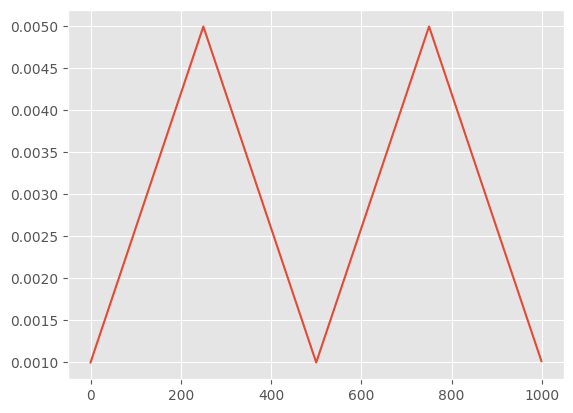

In [35]:
plot_lr(triangular(250, 0.005))

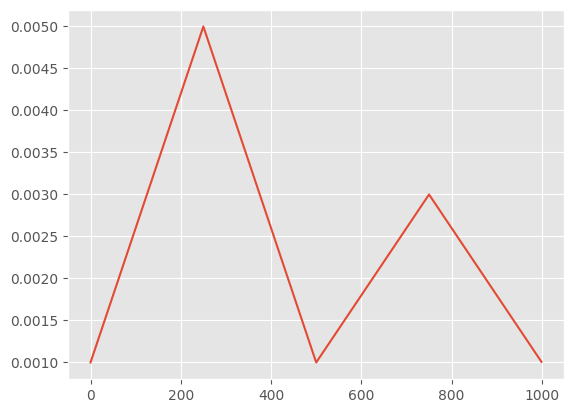

In [36]:
plot_lr(triangular(250, 0.005, 'triangular2'))

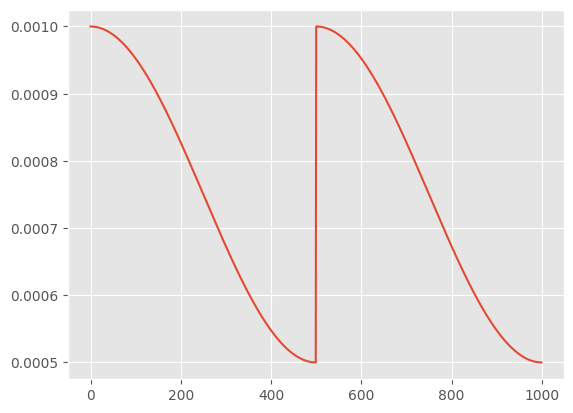

In [37]:
plot_lr(cosine(t_max=500, eta_min=0.0005))

## **6. 모델 학습하기**

In [38]:
# 데이터셋 분할, random state는 위에서 사전 정의 완료

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
datasets = {'train': (X_train, y_train), 'val': (X_valid, y_valid)}
dataset_sizes = {'train': len(X_train), 'val': len(X_valid)}

In [39]:
minmax = ratings.rating.min(), ratings.rating.max()
minmax

(0.5, 5.0)

In [40]:
net = EmbeddingNet(
    n_users=n, n_movies=m,
    n_factors=150, hidden=[500, 500, 500],
    embedding_dropout=0.05, dropouts=[0.5, 0.5, 0.25])

In [41]:
print(n,m)

610 9724


In [42]:
lr = 1e-3
wd = 1e-5
bs = 2000
n_epochs = 200
patience = 10
no_improvements = 0
best_loss = np.inf
best_weights = None
history = []
lr_history = []

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

net.to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = optim.Adam(net.parameters(), lr=lr, weight_decay=wd)
iterations_per_epoch = int(math.ceil(dataset_sizes['train'] // bs))
scheduler = CyclicLR(optimizer, cosine(t_max=iterations_per_epoch * 2, eta_min=lr/10))

for epoch in range(n_epochs):
    stats = {'epoch': epoch + 1, 'total': n_epochs}

    for phase in ('train', 'val'):
        training = phase == 'train'
        running_loss = 0.0
        n_batches = 0
        batch_num = 0
        for batch in batches(*datasets[phase], shuffle=training, bs=bs):
            x_batch, y_batch = [b.to(device) for b in batch]
            optimizer.zero_grad()
            # compute gradients only during 'train' phase
            with torch.set_grad_enabled(training):
                outputs = net(x_batch[:, 0], x_batch[:, 1], minmax)
                loss = criterion(outputs, y_batch)

                # don't update weights and rates when in 'val' phase
                if training:
                    scheduler.step()
                    loss.backward()
                    optimizer.step()
                    lr_history.extend(scheduler.get_lr())

            running_loss += loss.item()

        epoch_loss = running_loss / dataset_sizes[phase]
        stats[phase] = epoch_loss

        # early stopping: save weights of the best model so far
        if phase == 'val':
            if epoch_loss < best_loss:
                print('loss improvement on epoch: %d' % (epoch + 1))
                best_loss = epoch_loss
                best_weights = copy.deepcopy(net.state_dict())
                no_improvements = 0
            else:
                no_improvements += 1

    history.append(stats)
    print('[{epoch:03d}/{total:03d}] train: {train:.4f} - val: {val:.4f}'.format(**stats))
    if no_improvements >= patience:
        print('early stopping after epoch {epoch:03d}'.format(**stats))
        break

/tmp/ipykernel_15228/779182159.py:38: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


loss improvement on epoch: 1
[001/200] train: 0.9933 - val: 0.8506
loss improvement on epoch: 2
[002/200] train: 0.7742 - val: 0.8057
loss improvement on epoch: 3
[003/200] train: 0.7225 - val: 0.7659
loss improvement on epoch: 4
[004/200] train: 0.6522 - val: 0.7611
loss improvement on epoch: 5
[005/200] train: 0.6585 - val: 0.7556
loss improvement on epoch: 6
[006/200] train: 0.6147 - val: 0.7531
[007/200] train: 0.6244 - val: 0.7565
[008/200] train: 0.5834 - val: 0.7590
[009/200] train: 0.5915 - val: 0.7740
[010/200] train: 0.5449 - val: 0.7805
[011/200] train: 0.5476 - val: 0.7876
[012/200] train: 0.4907 - val: 0.8057
[013/200] train: 0.4874 - val: 0.8141
[014/200] train: 0.4294 - val: 0.8452
[015/200] train: 0.4229 - val: 0.8455
[016/200] train: 0.3738 - val: 0.8671
early stopping after epoch 016


## **7. 모델 평가하기**

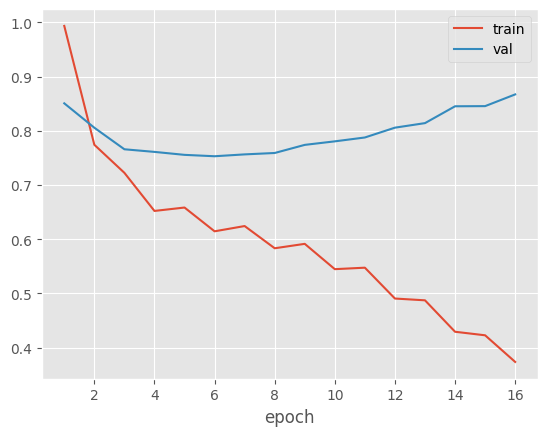

In [43]:
ax = pd.DataFrame(history).drop(columns='total').plot(x='epoch')


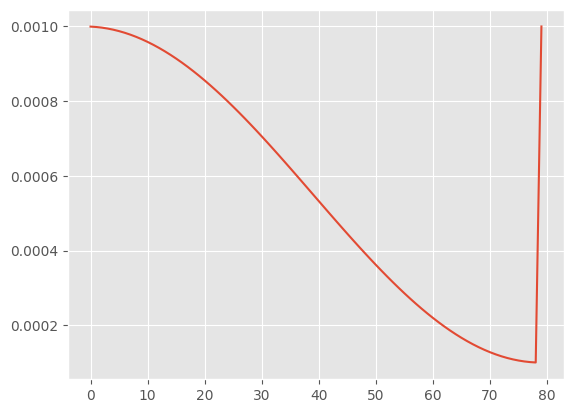

In [45]:
plt.plot(lr_history[:2*iterations_per_epoch])

In [46]:
net.load_state_dict(best_weights)

<All keys matched successfully>

In [47]:
groud_truth, predictions = [], []

with torch.no_grad():
    for batch in batches(*datasets['val'], shuffle=False, bs=bs):
        x_batch, y_batch = [b.to(device) for b in batch]
        outputs = net(x_batch[:, 0], x_batch[:, 1], minmax)
        groud_truth.extend(y_batch.tolist())
        predictions.extend(outputs.tolist())

groud_truth = np.asarray(groud_truth).ravel()
predictions = np.asarray(predictions).ravel()

In [48]:
final_loss = np.sqrt(np.mean((np.array(predictions) - np.array(groud_truth))**2))
print(f'Final RMSE: {final_loss:.4f}')

Final RMSE: 0.8704


## **8. 실험 수정**

n_Factor = 128, hidden_layer는 hidden = [128,64,32] 로 수정

In [94]:
# 데이터셋 분할, random state는 위에서 사전 정의 완료

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
datasets = {'train': (X_train, y_train), 'val': (X_valid, y_valid)}
dataset_sizes = {'train': len(X_train), 'val': len(X_valid)}

In [95]:
minmax = ratings.rating.min(), ratings.rating.max()
minmax

(0.5, 5.0)

In [96]:
EmbeddingNet(n, m,
    n_factors=128,
    hidden=[256,128,64],
    dropouts=[0.3,0.2,0.1]
)

EmbeddingNet(
  (u): Embedding(610, 128)
  (m): Embedding(9724, 128)
  (drop): Dropout(p=0.02, inplace=False)
  (hidden): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
  )
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [97]:
lr = 1e-3
wd = 1e-5
bs = 2000
n_epochs = 200
patience = 10
no_improvements = 0
best_loss = np.inf
best_weights = None
history = []
lr_history = []

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

net.to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = optim.AdamW(net.parameters(), lr=lr, weight_decay=wd)
iterations_per_epoch = int(math.ceil(dataset_sizes['train'] // bs))
scheduler = CyclicLR(optimizer, cosine(t_max=iterations_per_epoch * 2, eta_min=lr/10))

for epoch in range(n_epochs):
    stats = {'epoch': epoch + 1, 'total': n_epochs}

    for phase in ('train', 'val'):
        training = phase == 'train'
        running_loss = 0.0
        n_batches = 0
        batch_num = 0
        for batch in batches(*datasets[phase], shuffle=training, bs=bs):
            x_batch, y_batch = [b.to(device) for b in batch]
            optimizer.zero_grad()
            # compute gradients only during 'train' phase
            with torch.set_grad_enabled(training):
                outputs = net(x_batch[:, 0], x_batch[:, 1], minmax)
                loss = criterion(outputs, y_batch)

                # don't update weights and rates when in 'val' phase
                if training:
                    scheduler.step()
                    loss.backward()
                    optimizer.step()
                    lr_history.extend(scheduler.get_lr())

            running_loss += loss.item()

        epoch_loss = running_loss / dataset_sizes[phase]
        stats[phase] = epoch_loss

        # early stopping: save weights of the best model so far
        if phase == 'val':
            if epoch_loss < best_loss:
                print('loss improvement on epoch: %d' % (epoch + 1))
                best_loss = epoch_loss
                best_weights = copy.deepcopy(net.state_dict())
                no_improvements = 0
            else:
                no_improvements += 1

    history.append(stats)
    print('[{epoch:03d}/{total:03d}] train: {train:.4f} - val: {val:.4f}'.format(**stats))
    if no_improvements >= patience:
        print('early stopping after epoch {epoch:03d}'.format(**stats))
        break

/tmp/ipykernel_15228/1655585215.py:38: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


loss improvement on epoch: 1
[001/200] train: 5.0359 - val: 5.0600
[002/200] train: 5.0338 - val: 5.0600
[003/200] train: 5.0350 - val: 5.0600
[004/200] train: 5.0337 - val: 5.0600
[005/200] train: 5.0337 - val: 5.0600
[006/200] train: 5.0291 - val: 5.0600
[007/200] train: 5.0352 - val: 5.0600
[008/200] train: 5.0327 - val: 5.0600
[009/200] train: 5.0367 - val: 5.0600
[010/200] train: 5.0338 - val: 5.0600
[011/200] train: 5.0381 - val: 5.0600
early stopping after epoch 011


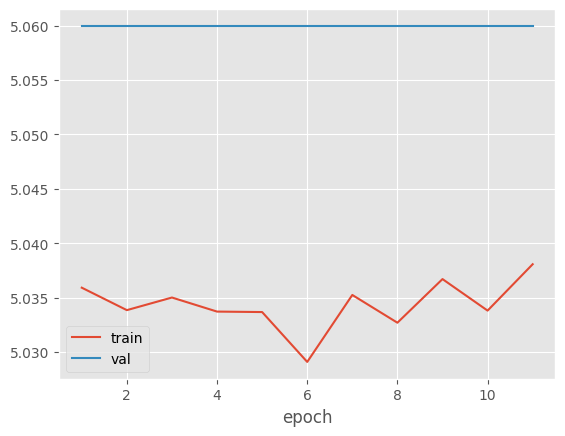

In [98]:
ax = pd.DataFrame(history).drop(columns='total').plot(x='epoch')


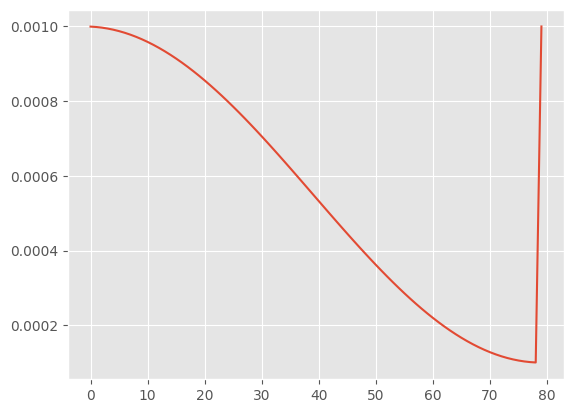

In [99]:
plt.plot(lr_history[:2*iterations_per_epoch])

In [87]:
net.load_state_dict(best_weights)

<All keys matched successfully>

In [88]:
groud_truth, predictions = [], []

with torch.no_grad():
    for batch in batches(*datasets['val'], shuffle=False, bs=bs):
        x_batch, y_batch = [b.to(device) for b in batch]
        outputs = net(x_batch[:, 0], x_batch[:, 1], minmax)
        groud_truth.extend(y_batch.tolist())
        predictions.extend(outputs.tolist())

groud_truth = np.asarray(groud_truth).ravel()
predictions = np.asarray(predictions).ravel()

final_loss = np.sqrt(np.mean((np.array(predictions) - np.array(groud_truth))**2))
print(f'Final RMSE: {final_loss:.4f}')

Final RMSE: 2.2589
